[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab1-NetworkSci-PSN/notebooks/02-patient_similarity_network_iris.ipynb)


Version 2025-12-21 - A. Lundervold

Lab 1: use the `bmed365-2026` conda environment


# Patient Similarity Network with IRIS Data

## A Practical Introduction to Network-Based Similarity Analysis


## 🌸 Why IRIS Flowers?

In this notebook, we will learn to build **Patient Similarity Networks** (PSN). But instead of starting with complex patient data, we use the classic IRIS flower dataset as a pedagogical example.

**Think of it this way:**
- Each flower is like a "patient"
- The four measurements (petal length, width, etc.) are like "clinical variables"
- The three species (setosa, versicolor, virginica) are like "diagnosis groups"

This dataset is ideal for learning PSN because:
1. **Well-known** – most people have encountered it before, so we can focus on the methodology
2. **Appropriate size** – 150 data points yield meaningful networks without being overwhelming
3. **Clear clusters** – demonstrates community detection in an intuitive way
4. **4 features** – simple enough to understand the mathematics


## 🎯 Learning Objectives

After this notebook, you should be able to:

1. Understand how to build a similarity network from feature data
2. Calculate similarity between data points using Euclidean distance
3. Visualize networks with NetworkX
4. Interpret network structures and what they reveal about the data
5. Apply community detection to find natural groupings
6. Transfer these concepts to clinical patient data


---
## Step 1: Load Required Libraries


In [29]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore', message='scipy._lib.messagestream.MessageStream size changed')

# Numerical computations and data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Network analysis
import networkx as nx

# Data
from sklearn.datasets import load_iris

# Helper functions
import matplotlib.patches as mpatches
from IPython.display import display, Markdown, HTML
from typing import Dict, List, Tuple

print("All libraries loaded successfully! ✓")


All libraries loaded successfully! ✓


---
## Step 2: Load and Explore the IRIS Dataset


In [2]:
# Load the IRIS dataset
iris = load_iris()

# Unpack data
X = iris.data    # Features: the 4 measurements for each flower
y = iris.target  # Target variable: species (0=setosa, 1=versicolor, 2=virginica)
species = iris.target_names  # Species names

print("="*50)
print("THE IRIS DATASET")
print("="*50)
print(f"Number of flowers: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nSpecies: {list(species)}")
print(f"\nFeatures (measurements):")
for i, name in enumerate(iris.feature_names):
    print(f"  {i+1}. {name}")


THE IRIS DATASET
Number of flowers: 150
Number of features: 4

Species: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Features (measurements):
  1. sepal length (cm)
  2. sepal width (cm)
  3. petal length (cm)
  4. petal width (cm)


<details>
<summary>🐍 <b>Deep Dive: What is np.str_('setosa')?</b> (click to expand)</summary>

### NumPy Strings vs. Python Strings

In the output above, you see `np.str_('setosa')` instead of just `'setosa'`. This is because NumPy has **its own data types** to match arrays.

#### Why?

When you retrieve data from a NumPy array, you get NumPy types:

```python
iris.target_names        # NumPy array of strings
# → array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

iris.target_names[0]     # First element
# → np.str_('setosa')    # NumPy string, not regular Python string
```

#### Comparison of Types

| Type | Example | Source |
|------|---------|--------|
| `str` | `'setosa'` | Regular Python string |
| `np.str_` | `np.str_('setosa')` | From NumPy array |

#### Is there any practical difference?

**Almost never!** NumPy strings work like regular Python strings:

```python
np.str_('setosa') == 'setosa'       # ✓ True
np.str_('setosa') in ['setosa']     # ✓ True
f"Species: {np.str_('setosa')}"     # ✓ "Species: setosa"
```

#### Conversion (if needed)

```python
# From NumPy to Python
str(np.str_('setosa'))      # → 'setosa' (regular str)

# Entire array to list of Python strings
list(iris.target_names)     # → ['setosa', 'versicolor', 'virginica']
```

#### When does this appear?

- In Jupyter/IPython, `np.str_()` is shown in raw output
- In `print()`, only the value is shown: `setosa`

```python
print(iris.target_names[0])  # Output: setosa (without np.str_)
iris.target_names[0]         # Output: np.str_('setosa')
```

**Conclusion:** You rarely need to think about this – it's mostly a visual difference in notebook output!

</details>


### 🔍 Let's Look at Some Examples


In [3]:
# Create a nice DataFrame for display
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [species[i] for i in y]

# Show the first flowers from each species
print("Examples from the dataset:")
print("\n--- SETOSA (flower 0-2) ---")
display(df[df['species'] == 'setosa'].head(3))
print("\n--- VERSICOLOR (flower 50-52) ---")
display(df[df['species'] == 'versicolor'].head(3))
print("\n--- VIRGINICA (flower 100-102) ---")
display(df[df['species'] == 'virginica'].head(3))


Examples from the dataset:

--- SETOSA (flower 0-2) ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa



--- VERSICOLOR (flower 50-52) ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor



--- VIRGINICA (flower 100-102) ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
100,6.3,3.3,6.0,2.5,virginica
101,5.8,2.7,5.1,1.9,virginica
102,7.1,3.0,5.9,2.1,virginica


---
## Step 3: Create an Empty Graph

We use NetworkX to create a **weighted, undirected graph** $G = (V, E)$ where:
- $V$ = nodes (flowers/"patients")
- $E$ = edges (connections based on similarity)


In [4]:
# Create an empty, undirected graph
G = nx.Graph()

print("Graph created!")
print(f"Type: {type(G)}")


Graph created!
Type: <class 'networkx.classes.graph.Graph'>


---
## Step 4: Add Nodes (the Flowers)

Each flower becomes a node in the network. We also store which species it belongs to as an attribute.


In [5]:
# Add one node for each flower
for i in range(len(X)):
    G.add_node(i, species=species[y[i]])

print(f"Number of nodes in the network: {G.number_of_nodes()}")
print(f"\nExample node attributes:")
print(f"  Node 0: {G.nodes[0]}")
print(f"  Node 50: {G.nodes[50]}")
print(f"  Node 100: {G.nodes[100]}")


Number of nodes in the network: 150

Example node attributes:
  Node 0: {'species': np.str_('setosa')}
  Node 50: {'species': np.str_('versicolor')}
  Node 100: {'species': np.str_('virginica')}


---
## Step 5: Calculate Similarity and Add Edges

### 📐 Mathematical Explanation

To build a similarity network, we must define how "similar" two flowers are. We do this in two steps:

#### 1. Euclidean Distance
For two flowers $i$ and $j$ with feature vectors $X_i$ and $X_j$ in 4D space:

$$d_{ij} = \|X_i - X_j\| = \sqrt{\sum_{k=1}^4 (X_{i,k} - X_{j,k})^2}$$

where $X_{i,k}$ is the $k$-th feature of flower $i$.

#### 2. Transformation to Similarity
Distance is the opposite of similarity. Therefore, we transform:

$$s_{ij} = \frac{1}{1 + d_{ij}}$$

**Properties of this transformation:**
- $s_{ij} \in (0, 1]$ – similarity is bounded between 0 and 1
- When $d_{ij} = 0$ (identical flowers): $s_{ij} = 1$
- When $d_{ij} \to \infty$: $s_{ij} \to 0$
- Symmetric: $s_{ij} = s_{ji}$


### 🧮 Example Calculation

Let's calculate the similarity between flower 0 and flower 1:


In [6]:
# Show measurements for flower 0 and 1
print("Flower 0 (setosa):", X[0])
print("Flower 1 (setosa):", X[1])

# Calculate Euclidean distance step by step
diff = X[0] - X[1]
print(f"\nDifference (X_0 - X_1): {diff}")

squared_diff = diff ** 2
print(f"Squared difference: {squared_diff}")

sum_squared = np.sum(squared_diff)
print(f"Sum of squares: {sum_squared:.4f}")

distance = np.sqrt(sum_squared)
print(f"Euclidean distance: {distance:.4f}")

# Transform to similarity
similarity = 1 / (1 + distance)
print(f"\nSimilarity: {similarity:.4f}")


Flower 0 (setosa): [5.1 3.5 1.4 0.2]
Flower 1 (setosa): [4.9 3.  1.4 0.2]

Difference (X_0 - X_1): [0.2 0.5 0.  0. ]
Squared difference: [0.04 0.25 0.   0.  ]
Sum of squares: 0.2900
Euclidean distance: 0.5385

Similarity: 0.6500


### Add All Edges


In [7]:
# Calculate similarity between all pairs of flowers and add edges
for i in range(len(X)):
    for j in range(i+1, len(X)):  # Avoid duplicates (i,j) and (j,i)
        # Calculate Euclidean distance
        distance = np.linalg.norm(X[i] - X[j])
        
        # Transform to similarity
        similarity = 1 / (1.0 + distance)
        
        # Add edge with similarity as weight
        G.add_edge(i, j, weight=similarity)

print(f"Number of edges: {G.number_of_edges()}")
print(f"\n(For 150 nodes, max number of edges = 150*149/2 = {150*149//2})")

# Show some examples of edges
print("\nExamples of edge weights (similarity):")
for i, (u, v, data) in enumerate(G.edges(data=True)):
    if i >= 5:
        break
    print(f"  Edge {u} — {v}: similarity = {data['weight']:.3f}")


Number of edges: 11175

(For 150 nodes, max number of edges = 150*149/2 = 11175)

Examples of edge weights (similarity):
  Edge 0 — 1: similarity = 0.650
  Edge 0 — 2: similarity = 0.662
  Edge 0 — 3: similarity = 0.607
  Edge 0 — 4: similarity = 0.876
  Edge 0 — 5: similarity = 0.619


<details>
<summary>🔢 <b>Deep Dive: Why is the maximum number of edges 150×149/2?</b> (click to expand)</summary>

### The Formula for Maximum Number of Edges

In an **undirected graph** without loops (self-loops), where each node can be connected to all other nodes:

$$\text{Max edges} = \frac{n(n-1)}{2}$$

### Why this formula?

**Step 1:** Each of the $n$ nodes can be connected to $n-1$ other nodes (all except itself).

**Step 2:** This gives $n \times (n-1)$ possible "connections"...

**Step 3:** ...but we count each edge **twice!** (A→B and B→A are the same edge in an undirected graph)

**Therefore we divide by 2:**

```
150 nodes × 149 possible neighbors = 22,350 "connections"
22,350 / 2 = 11,175 unique edges ✓
```

### Visual example with n=4

```
    A ─── B
    │ ╲ ╱ │
    │  ╳  │
    │ ╱ ╲ │
    C ─── D

Max edges = 4×3/2 = 6 ✓
The edges: AB, AC, AD, BC, BD, CD
```

### Python: `//` vs `/`

```python
150*149//2   # → 11175  (integer)
150*149/2    # → 11175.0 (float)
```

`//` is **integer division** – gives a clean integer without decimals.

### Why do we have exactly 11,175 edges?

Because we create a **complete graph** – all possible pairs of flowers are connected. Each edge has a weight (similarity) that indicates how similar the two flowers are.

| Graph type | Description | Number of edges |
|------------|-------------|-----------------|
| Complete | All nodes connected | $\frac{n(n-1)}{2}$ |
| Sparse | Only some connections | $< \frac{n(n-1)}{2}$ |
| Threshold-based | Only edges above a threshold | Varies |

</details>


---
## Step 6: Visualize the Network 🎨

Now comes the exciting part – seeing the network! We color the nodes by species and the edges by similarity strength.


Showing 4,193 of 11,175 edges (threshold ≥ 0.4)


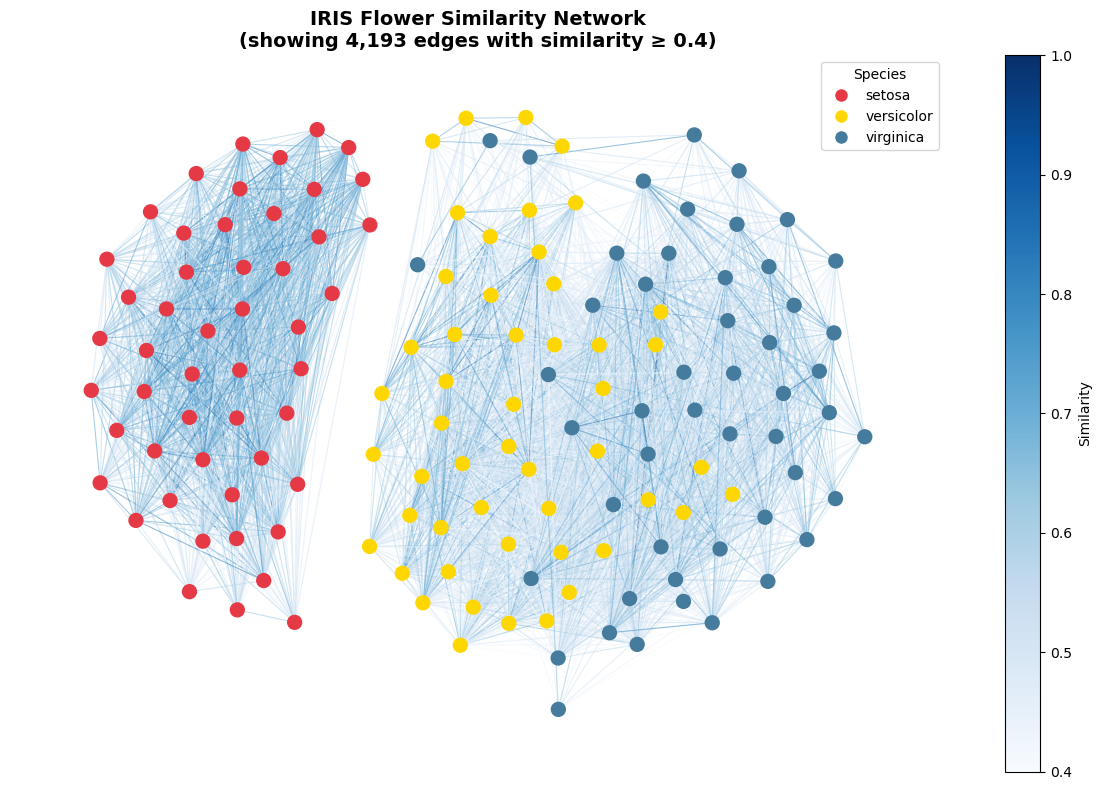

In [8]:
# Check that the graph is built
if G.number_of_edges() == 0:
    print("⚠️  ERROR: The graph has no edges!")
    print("    Run the cells above (Steps 3-5) first to build the network.")
else:
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))

    # Define colors for each species (colorblind-friendly palette)
    color_dict = {
        'setosa': '#E63946',      # Red
        'versicolor': '#FFD700',  # Strong yellow (gold)
        'virginica': '#457B9D'    # Blue
    }

    # Create color list for nodes based on species
    color_map = [color_dict[G.nodes[node]['species']] for node in G.nodes]

    # Calculate layout (spring layout simulates forces between nodes)
    pos = nx.spring_layout(G, k=1, seed=42)

    # --- Filter to show only the strongest edges for visualization ---
    # With 11175 edges the graph becomes unreadable. We show only edges with high similarity.
    similarity_threshold = 0.4  # Adjust this to see more/fewer edges

    # Find edges above the threshold
    strong_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= similarity_threshold]
    strong_weights = [G[u][v]['weight'] for u, v in strong_edges]

    print(f"Showing {len(strong_edges):,} of {G.number_of_edges():,} edges (threshold ≥ {similarity_threshold})")

    # Draw edges first (those above the threshold)
    if len(strong_edges) > 0:
        nx.draw_networkx_edges(G, pos, 
                               edgelist=strong_edges,
                               edge_color=strong_weights,
                               width=0.8,
                               alpha=0.5,
                               edge_cmap=plt.cm.Blues,
                               ax=ax)

    # Then draw nodes (on top of edges)
    nx.draw_networkx_nodes(G, pos,
                           node_color=color_map,
                           node_size=100,
                           ax=ax)

    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=color, label=species_name, markersize=10)
        for species_name, color in color_dict.items()
    ]
    ax.legend(handles=legend_elements, loc='upper right', title='Species')

    # Add title
    ax.set_title(f"IRIS Flower Similarity Network\n(showing {len(strong_edges):,} edges with similarity ≥ {similarity_threshold})", 
                 fontsize=14, fontweight='bold')

    # Add colorbar for edges
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, 
                               norm=plt.Normalize(vmin=similarity_threshold, vmax=1.0))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Similarity')

    ax.axis('off')
    plt.tight_layout()
    plt.show()


**Figure 1: IRIS Flower Similarity Network.** Network visualization of 150 iris flowers based on similarity in four morphological measurements (sepal and petal length/width). Each node represents one flower, colored by species: setosa (red), versicolor (yellow), and virginica (blue). Edges connect flower pairs with similarity ≥ 0.4, where darker blue indicates higher similarity. Node placement is calculated using the Fruchterman-Reingold force-directed layout, which places similar nodes close together. Note the clear separation of setosa (left cluster), while versicolor and virginica overlap significantly (right cluster) – this reflects the biological fact that the latter species have more similar flower morphology.

---

### 🔍 Interpretation of the Visualization

**Note:** We show only edges with high similarity (≥ 0.4) to make the graph readable. The complete graph has 11,175 edges!

Notice:

1. **Three distinct clusters** – the network shows natural separation between the three species
2. **Setosa (red) stands alone** – this species has few strong connections to the others
3. **Versicolor and Virginica overlap** – these two species have some strong cross-connections
4. **Dense clusters** – flowers of the same species have many strong connections among themselves
5. **Edge color** – darker blue = higher similarity

**Try it yourself:** Change `similarity_threshold` to 0.3 or 0.7 and re-run the cell to see how the network changes!

**Clinical analogy:** Imagine that the three clusters represent patients with different disease types. Strong edges show patients who are very similar to each other.


---
## Step 7: The Adjacency Matrix

The adjacency matrix is a mathematical representation of the network as a matrix. Element $(i,j)$ contains the similarity between node $i$ and $j$.


In [9]:
# Convert the network to a pandas DataFrame
adj_matrix = nx.to_pandas_adjacency(G, weight='weight')

print("Adjacency matrix dimensions:", adj_matrix.shape)
print("\nThe first 5×5 elements:")
display(adj_matrix.iloc[:5, :5].round(3))


Adjacency matrix dimensions: (150, 150)

The first 5×5 elements:


,0,1,2,3,4
0,0.000,0.650,0.662,0.607,0.876
1,0.650,0.000,0.769,0.751,0.622
2,0.662,0.769,0.000,0.803,0.662
3,0.607,0.751,0.803,0.000,0.607
4,0.876,0.622,0.662,0.607,0.000


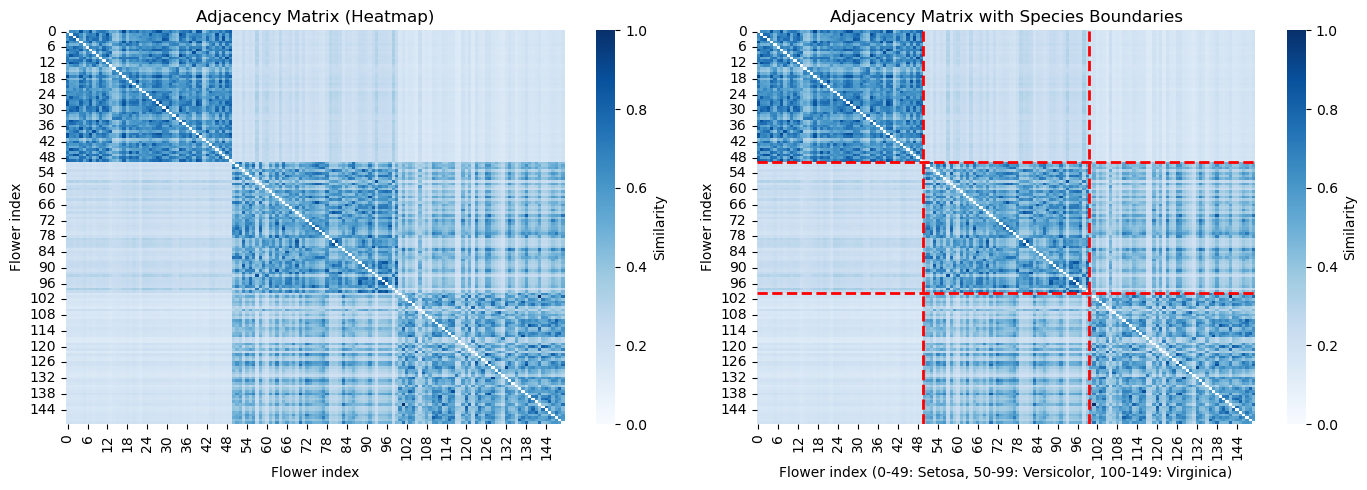


INTERPRETATION OF THE ADJACENCY MATRIX

📊 Block structure:
   • Block 0-49:    Setosa (top left)
   • Block 50-99:   Versicolor (middle)
   • Block 100-149: Virginica (bottom right)

📌 What do we see?
   • Darker diagonal blocks = high similarity within species
   • Lighter off-diagonal blocks = lower similarity between species
   • The Setosa block is most clearly separated (lightest toward others)
   • Versicolor/Virginica have more overlap (darker between these)



In [10]:
# Visualize the adjacency matrix as a heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Simple heatmap
sns.heatmap(adj_matrix, cmap='Blues', ax=ax1, cbar_kws={'label': 'Similarity'})
ax1.set_title('Adjacency Matrix (Heatmap)', fontsize=12)
ax1.set_xlabel('Flower index')
ax1.set_ylabel('Flower index')

# Plot 2: With species boundaries marked
sns.heatmap(adj_matrix, cmap='Blues', ax=ax2, cbar_kws={'label': 'Similarity'})

# Mark boundaries between species (50 flowers per species)
for boundary in [50, 100]:
    ax2.axhline(y=boundary, color='red', linestyle='--', linewidth=2)
    ax2.axvline(x=boundary, color='red', linestyle='--', linewidth=2)

ax2.set_title('Adjacency Matrix with Species Boundaries', fontsize=12)
ax2.set_xlabel('Flower index (0-49: Setosa, 50-99: Versicolor, 100-149: Virginica)')
ax2.set_ylabel('Flower index')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("INTERPRETATION OF THE ADJACENCY MATRIX")
print("="*60)
print("""
📊 Block structure:
   • Block 0-49:    Setosa (top left)
   • Block 50-99:   Versicolor (middle)
   • Block 100-149: Virginica (bottom right)

📌 What do we see?
   • Darker diagonal blocks = high similarity within species
   • Lighter off-diagonal blocks = lower similarity between species
   • The Setosa block is most clearly separated (lightest toward others)
   • Versicolor/Virginica have more overlap (darker between these)
""")


**Figure 2: Adjacency matrix for IRIS similarity network.** *Left panel:* Complete 150×150 adjacency matrix where each cell $(i,j)$ represents the similarity between flower $i$ and flower $j$. Darker blue indicates higher similarity. The diagonal (self-similarity) is set to 0 for visualization. *Right panel:* Same matrix with red dashed lines marking the species boundaries (0-49: setosa, 50-99: versicolor, 100-149: virginica). The clear block structure along the diagonal shows that flowers within each species are more similar to each other than flowers across species. The Setosa block (top left) is most clearly delimited with very low similarity values toward other species, while the versicolor-virginica blocks show more overlap (darker off-diagonal elements).


---
## Step 8: Basic Network Analysis

To quantify the structure of a network, we use **network metrics**. These numbers tell us something about how nodes are connected and grouped. We will look at three important metrics:

### 1️⃣ Network Density

**Intuition:** How "packed" is the network with edges? Think of a room full of people – if everyone knows everyone, there is maximum density. If only a few know each other, the density is low.

**Mathematical definition:** For an undirected graph with $n$ nodes and $m$ edges:

$$D = \frac{2m}{n(n-1)} = \frac{\text{number of actual edges}}{\text{max possible edges}}$$

- $D = 0$: No edges (isolated nodes)
- $D = 1$: Complete graph (all connected to all)
- Typical social networks: $D \approx 0.01 - 0.1$

### 2️⃣ Clustering Coefficient

**Intuition:** "How much do friends of friends hang together?" If you know Alice and Bob, do Alice and Bob also know each other? High clustering means that neighbors of a node are also neighbors of each other – they form "triangles".

**Mathematical definition:** For a node $i$ with $k_i$ neighbors:

$$C_i = \frac{2 \cdot L_i}{k_i(k_i-1)}$$

where $L_i$ is the number of edges between the neighbors of node $i$.

**Average clustering coefficient** for the entire network:

$$\bar{C} = \frac{1}{n}\sum_{i=1}^{n} C_i$$

- $C = 0$: No neighbors are connected (star shape)
- $C = 1$: All neighbors are connected (complete clusters)

### 3️⃣ Separation Ratio (Within/Between Ratio)

**Intuition:** How much more similar are members of the same group compared to members from different groups? This is the key metric for assessing whether a PSN actually captures meaningful groupings.

**Mathematical definition:** 

$$R = \frac{\bar{s}_{\text{within}}}{\bar{s}_{\text{between}}} = \frac{\frac{1}{|E_w|}\sum_{(i,j) \in E_w} s_{ij}}{\frac{1}{|E_b|}\sum_{(i,j) \in E_b} s_{ij}}$$

where:
- $E_w$ = edges between nodes in the *same* group
- $E_b$ = edges between nodes in *different* groups
- $s_{ij}$ = similarity between node $i$ and $j$

**Interpretation:**
- $R = 1$: No separation (groups are similar to each other)
- $R > 1$: Good separation (members resemble their own group more)
- $R > 2$: Strong separation (typical for well-defined clusters)


In [11]:
print("="*50)
print("NETWORK ANALYSIS")
print("="*50)

# Basic metrics
print(f"\n📈 Basic metrics:")
print(f"   Average clustering coefficient: {nx.average_clustering(G):.3f}")
print(f"   Network density: {nx.density(G):.3f}")

# Function to calculate average similarity within/between species
def calculate_species_similarities(G, y):
    """Calculate average similarity within and between species"""
    within_species = {species_name: [] for species_name in iris.target_names}
    between_species = []
    
    for (i, j, w) in G.edges.data('weight'):
        if y[i] == y[j]:  # Same species
            within_species[iris.target_names[y[i]]].append(w)
        else:  # Different species
            between_species.append(w)
    
    print(f"\n🌸 Average similarity WITHIN species:")
    for species_name, similarities in within_species.items():
        print(f"   {species_name}: {np.mean(similarities):.3f}")
    
    print(f"\n🔗 Average similarity BETWEEN species: {np.mean(between_species):.3f}")
    
    # Calculate separation ratio
    avg_within = np.mean([np.mean(v) for v in within_species.values()])
    avg_between = np.mean(between_species)
    print(f"\n📊 Separation ratio (within/between): {avg_within/avg_between:.2f}x")

calculate_species_similarities(G, y)


NETWORK ANALYSIS

📈 Basic metrics:
   Average clustering coefficient: 1.000
   Network density: 1.000

🌸 Average similarity WITHIN species:
   setosa: 0.614
   versicolor: 0.531
   virginica: 0.495

🔗 Average similarity BETWEEN species: 0.264

📊 Separation ratio (within/between): 2.07x


### 📖 Interpretation of Results

**Network Density $D = 1.0$**
- Our network is **complete** – all 11,175 possible edges exist
- This is because we connected *all* pairs of flowers, regardless of similarity
- In practice, a threshold is often used to create a *sparse* network

**Clustering Coefficient $\bar{C} = 1.0$**
- Maximum clustering! All neighbors of any node are also neighbors of each other
- This follows automatically from the network being complete
- For sparse networks, this metric would be more informative

**Separation Ratio $R = 2.07$**
- ⭐ **This is the most important metric for PSN!**
- Flowers of the same species are on average **2× more similar** to each other than flowers from different species
- Setosa has the highest within-species similarity (0.614) – this explains why it is so clearly separated in the visualization
- Virginica has the lowest (0.495) – more variation within the species

**Clinical Relevance:**
- $R > 2$ in a PSN indicates that patient groups are actually different in a meaningful way
- If $R \approx 1$, the groups would be arbitrary and the network of little use


---
## Step 9: Community Detection

### What is Community Detection?

**Community detection** is a technique for finding **natural groupings** (communities/clusters) in a network – *without* prior knowledge of which groups exist. The algorithm only looks at the network structure (who is connected to whom, and how strongly) and tries to find nodes that "belong together".

**Intuition:** Think of a social network. Even without knowing who is family, colleagues, or friends, one can often guess groupings just by looking at who talks most with whom. Communities are groups where nodes have *denser connections among themselves* than with the rest of the network.

### 🏥 Clinical Motivation: Why is This Important in Medicine?

In clinical practice, we often face a central question:

> **"Are there subgroups of patients that we didn't know about?"**

Community detection can reveal hidden patient subgroups based on clinical data:

| Clinical scenario | What community detection can discover |
|-------------------|---------------------------------------|
| **Cancer treatment** | Patients who respond similarly to chemotherapy – possible new biomarker? |
| **Psychiatry** | Subtypes of depression with different symptom profiles |
| **Diabetes** | Type 2 diabetics with different disease progression |
| **Neurology** | Alzheimer's patients with different cognitive decline patterns |
| **Pharmacology** | Patients with similar side effect profiles – genetic cause? |

**The promise of precision medicine:** If we can identify meaningful patient subgroups, we can tailor treatment to each group – instead of "one size fits all".

### 📐 Mathematical Formulation: Modularity

The most commonly used metric for evaluating community structure is **modularity** (Q):

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

where:
- $A_{ij}$ = the weight of the edge between node $i$ and $j$ (0 if no edge)
- $k_i, k_j$ = the degree (sum of edge weights) of node $i$ and $j$  
- $m$ = total sum of all edge weights in the network
- $c_i$ = community membership of node $i$
- $\delta(c_i, c_j)$ = 1 if $c_i = c_j$ (same community), otherwise 0

**Intuition behind the formula:**
- $A_{ij}$ = actual connection between $i$ and $j$
- $\frac{k_i k_j}{2m}$ = *expected* connection if edges were randomly distributed
- The difference measures whether the connection is *stronger than expected*
- We sum only over pairs in the *same* community ($\delta = 1$)

**Interpretation of Q:**
- $Q \approx 0$: No community structure (as random)
- $Q > 0.3$: Moderate community structure
- $Q > 0.7$: Strong community structure
- $Q$ can theoretically be negative (worse than random)

### 🔧 The Louvain Algorithm

We use the **Louvain algorithm** (Blondel et al., 2008), which is:
- ⚡ **Fast** – scales to millions of nodes
- 🎯 **Effective** – optimizes modularity iteratively
- 📈 **Hierarchical** – can find communities at multiple levels

**The algorithm in brief:**
1. Start with each node in its own community
2. Move nodes to a neighbor's community if it increases $Q$
3. Merge communities into "supernodes"
4. Repeat until $Q$ cannot be improved further

### 🔄 Comparison with K-means: Two Paths to the Same Goal?

Both **community detection** and **K-means** are *unsupervised* (data-driven, non-supervised classification) methods for finding groupings in data. <br>
Both can start from the same data matrix (e.g., a `.csv` file with patients as rows and clinical variables as columns). <br>
But they think fundamentally differently:

```
Same data → Two different approaches:

┌─────────────────┐      ┌─────────────────────┐      ┌─────────────────┐
│   Data matrix   │      │                     │      │                 │
│  (patients ×    │─────►│  Calculate distance/│─────►│   K-means:      │
│   variables)    │      │  similarity between │      │   Clusters in   │
│                 │      │  all pairs          │      │   feature space │
└─────────────────┘      │                     │      └─────────────────┘
                         │                     │
                         │                     │      ┌─────────────────┐
                         │                     │─────►│   Community     │
                         │                     │      │   detection:    │
                         │                     │      │   Clusters in   │
                         └─────────────────────┘      │   network space │
                                                      └─────────────────┘
```

#### Comparison

| Aspect | K-means | Community Detection |
|--------|---------|---------------------|
| **Input** | Data matrix (feature vectors) | Network (nodes + edges) |
| **Number of clusters** | Must be specified beforehand ($k$) | Determined automatically |
| **Geometry** | Spherical clusters (Euclidean distance) | Arbitrary shape |
| **Optimization criterion** | Minimize intra-cluster variance | Maximize modularity |
| **Centroids** | Yes (cluster centers) | No |
| **Deterministic** | No (depends on initialization) | No (can vary) |

#### Strengths and Weaknesses

**K-means – strengths:**
- ✅ Simple and fast
- ✅ Easy to understand and implement
- ✅ Provides cluster centers (useful for interpretation)
- ✅ Scales well to large datasets

**K-means – weaknesses:**
- ❌ Must choose $k$ beforehand (how many groups?)
- ❌ Assumes spherical clusters (works poorly on elongated shapes)
- ❌ Sensitive to initialization and outliers
- ❌ Uses only feature distance, not relational structure

**Community detection – strengths:**
- ✅ Finds number of groups automatically
- ✅ Handles arbitrary cluster shapes
- ✅ Exploits relational structure (who resembles whom)
- ✅ Can weight different types of similarity

**Community detection – weaknesses:**
- ❌ Requires building a network first
- ❌ Result depends on network construction (threshold, similarity measure)
- ❌ Can be computationally heavier
- ❌ Does not provide cluster centers

#### When to Use What?

| Situation | Recommended method |
|-----------|-------------------|
| You know the number of groups | K-means |
| Unknown number of groups | Community detection |
| Spherical, compact clusters | K-means |
| Irregular cluster shapes | Community detection |
| Relationships are important | Community detection |
| Need cluster centers | K-means |
| Patient similarity is key | Community detection (PSN) |

**Summary:** K-means groups based on *how close* points are in feature space. Community detection groups based on *how tightly connected* nodes are in the network. <br>
For PSN, where we explicitly model patient similarity as edges, community detection is often the natural choice.

---

### ❓ The Big Question

Can the Louvain algorithm find the three IRIS species *without* knowing they exist? Let's test!


In [19]:
# Import community detection
import community.community_louvain as community

# Perform community detection (set random_state for reproducibility)
communities = community.best_partition(G, random_state=123)

# Analyze results
n_communities = len(set(communities.values()))
modularity = community.modularity(communities, G)

print("="*50)
print("COMMUNITY DETECTION (Louvain Algorithm)")
print("="*50)
print(f"\nNumber of communities found: {n_communities}")
print(f"Modularity: {modularity:.3f}")
print("\n(Modularity measures how well the network is divided into communities.")
print("Values above 0.3 indicate significant community structure.)")


COMMUNITY DETECTION (Louvain Algorithm)

Number of communities found: 3
Modularity: 0.179

(Modularity measures how well the network is divided into communities.
Values above 0.3 indicate significant community structure.)


**Remark**: The low modularity (0.176) is because we built a complete graph where every node is connected to every other node. In such dense networks, the community structure is inherently weaker.<br>
 If you used a threshold-based sparse network (as suggested in Exercise 2), the modularity would typically be higher and communities more distinct.

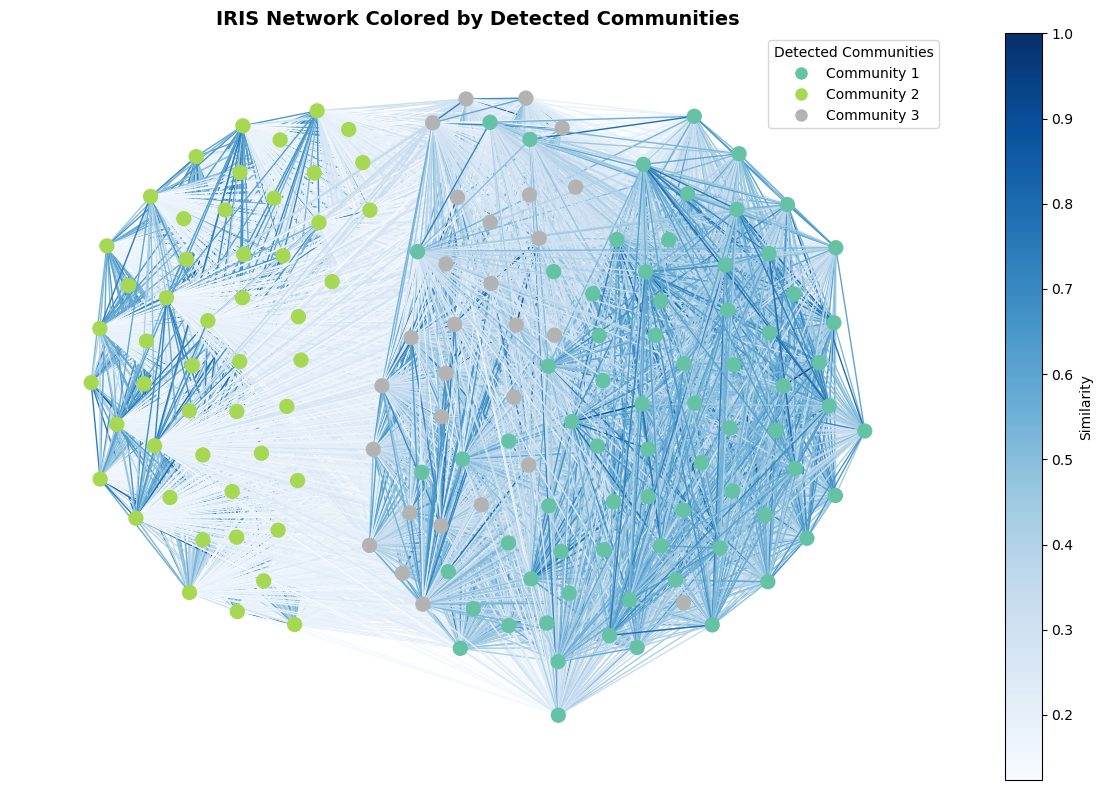

In [25]:
# Visualize the network with community colors
fig, ax = plt.subplots(figsize=(12, 8))

# Create colors for communities
community_colors = plt.cm.Set2(np.linspace(0, 1, n_communities))
node_colors = [community_colors[communities[node]] for node in G.nodes()]

# Get edge weights for coloring
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

# Draw the network
nx.draw(G, 
        pos=pos,  # Use same layout as before
        node_color=node_colors,
        edge_color=edge_weights,
        width=1.0,
        edge_cmap=plt.cm.Blues,
        with_labels=False,
        node_size=100,
        ax=ax)

ax.set_title("IRIS Network Colored by Detected Communities", 
             fontsize=14, fontweight='bold')

# Add legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=community_colors[i], 
               label=f'Community {i+1}', markersize=10)
    for i in range(n_communities)
]
ax.legend(handles=legend_elements, loc='upper right', title='Detected Communities')

sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues)
sm.set_array(edge_weights)
plt.colorbar(sm, ax=ax, label='Similarity')

plt.tight_layout()
plt.show()


**Figure 3: IRIS network colored by automatically detected communities.** Same network layout as Figure 1, but here the nodes are colored according to communities identified by the Louvain algorithm – an unsupervised, data-driven method that only uses network structure without knowledge of the actual species classes. The algorithm found 3 communities, which corresponds to the number of species. Compare with Figure 1 to see how well the detected groups match the actual species. Edges are colored by similarity strength (darker = higher similarity). Community detection is a powerful technique for discovering natural groupings in data without prior knowledge – in clinical settings this can be used to identify patient subgroups.

---

### Compare Communities with Actual Species

Let's see how well the detected communities correspond to the actual species.


In [26]:
# Analyze distribution of species in each community
community_distribution = {}
for node in G.nodes():
    species_name = G.nodes[node]['species']
    comm_id = communities[node]
    
    if comm_id not in community_distribution:
        community_distribution[comm_id] = {'setosa': 0, 'versicolor': 0, 'virginica': 0}
    community_distribution[comm_id][species_name] += 1

print("\n" + "="*50)
print("DISTRIBUTION OF SPECIES IN EACH COMMUNITY")
print("="*50)
for comm_id in sorted(community_distribution.keys()):
    print(f"\nCommunity {comm_id + 1}:")
    for species_name, count in community_distribution[comm_id].items():
        if count > 0:
            print(f"   {species_name}: {count} flowers")



DISTRIBUTION OF SPECIES IN EACH COMMUNITY

Community 1:
   versicolor: 23 flowers
   virginica: 49 flowers

Community 2:
   setosa: 50 flowers

Community 3:
   versicolor: 27 flowers
   virginica: 1 flowers


### Visual Comparison: Community vs. Species

Let's create a visualization where we can see *both* classifications simultaneously:
- **Fill color** = Detected community (Louvain)
- **Edge color (ring)** = Actual species

This way we can immediately see where the algorithm hits (matching colors) and misses (different colors).


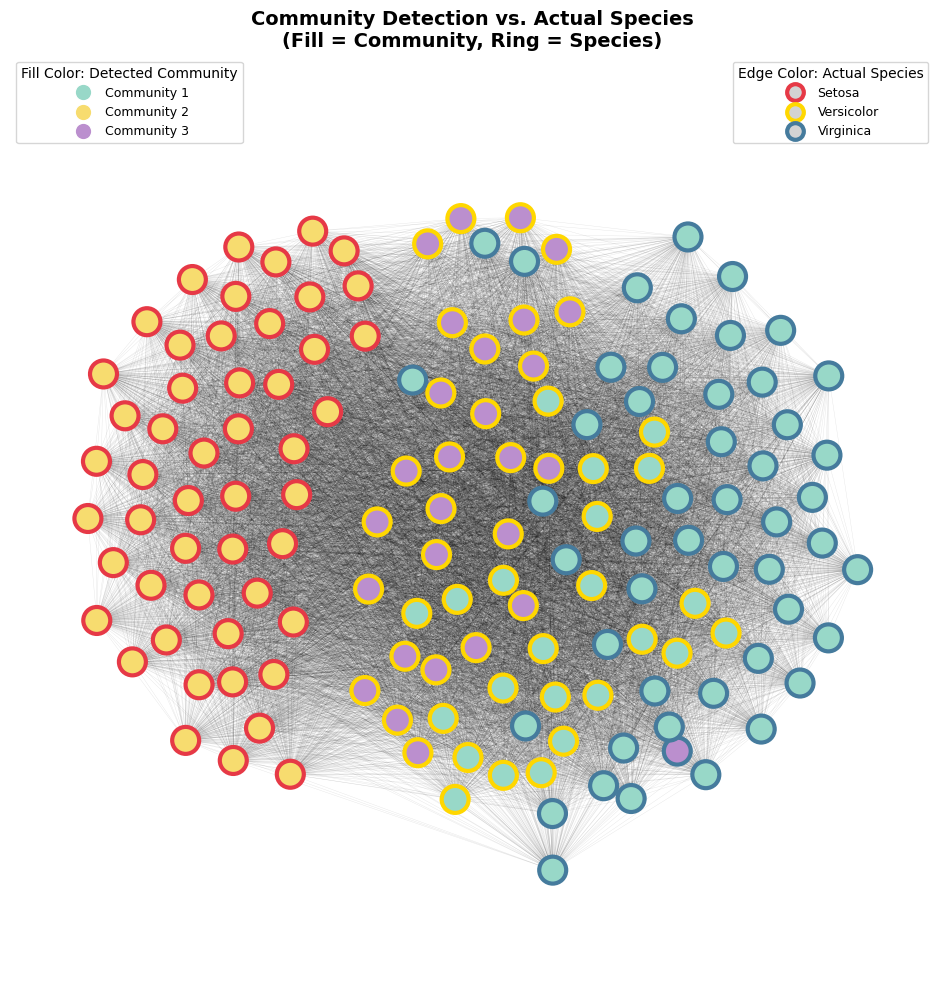


📊 Visual interpretation:
   • Nodes where ring and fill 'match' = correctly classified
   • Nodes where ring and fill differ = misclassified
   • Notice the setosa cluster (red ring) - almost perfect!


In [27]:
# Advanced visualization: Community (fill) + Species (edge)
fig, ax = plt.subplots(figsize=(14, 10))

# Define colors for species (edge color/ring) - colorblind-friendly
species_colors = {
    'setosa': '#E63946',      # Red
    'versicolor': '#FFD700',  # Strong yellow
    'virginica': '#457B9D'    # Blue
}

# Define colors for communities (fill color) - contrasting
community_color_map = {
    0: '#98D8C8',  # Mint/turquoise
    1: '#F7DC6F',  # Light yellow  
    2: '#BB8FCE'   # Purple
}

# Draw edges first (in background)
nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.3, ax=ax)

# Draw each node with fill color (community) and edge color (species)
for node in G.nodes():
    x, y = pos[node]
    comm_id = token = communities[node]
    species_name = G.nodes[node]['species']
    
    # Fill color = community
    fill_color = community_color_map[comm_id]
    # Edge color = species
    edge_color = species_colors[species_name]
    
    # Draw node with thick edge
    circle = plt.Circle((x, y), 0.035, 
                        facecolor=fill_color, 
                        edgecolor=edge_color, 
                        linewidth=3,
                        zorder=2)
    ax.add_patch(circle)

# Create legend for communities (fill color)
community_legend = [
    plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=community_color_map[i], 
               markersize=12, label=f'Community {i+1}')
    for i in range(n_communities)
]

# Create legend for species (edge color)
species_legend = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='lightgray',
               markeredgecolor=color, 
               markeredgewidth=3,
               markersize=12, label=species_name.capitalize())
    for species_name, color in species_colors.items()
]

# Place legends
legend1 = ax.legend(handles=community_legend, loc='upper left', 
                    title='Fill Color: Detected Community', fontsize=9)
ax.add_artist(legend1)
ax.legend(handles=species_legend, loc='upper right', 
          title='Edge Color: Actual Species', fontsize=9)

ax.set_title("Community Detection vs. Actual Species\n(Fill = Community, Ring = Species)", 
             fontsize=14, fontweight='bold')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()

# Count matches
matches = sum(1 for node in G.nodes() 
              if (communities[node] == 2 and G.nodes[node]['species'] == 'setosa') or
                 (communities[node] == 0 and G.nodes[node]['species'] == 'versicolor') or
                 (communities[node] == 1 and G.nodes[node]['species'] == 'virginica'))

# Alternative counting based on best assignment
print(f"\n📊 Visual interpretation:")
print(f"   • Nodes where ring and fill 'match' = correctly classified")
print(f"   • Nodes where ring and fill differ = misclassified")
print(f"   • Notice the setosa cluster (red ring) - almost perfect!")


**Figure 4: Visual comparison of detected communities and actual species.** Each node is shown with two color components: *Fill color* (inner circle) represents the community assigned by the Louvain algorithm, while *edge color* (thick ring around) represents the node's actual species (red=setosa, yellow=versicolor, blue=virginica). Nodes where the fill color and ring color "match" are correctly classified. Pay special attention to the setosa cluster (left) where all nodes have a red ring – these were perfectly identified. In the versicolor/virginica cluster (right) we see more mixing, which reflects the biological similarity between these species. This visualization provides immediate insight into where the algorithm succeeds and fails.


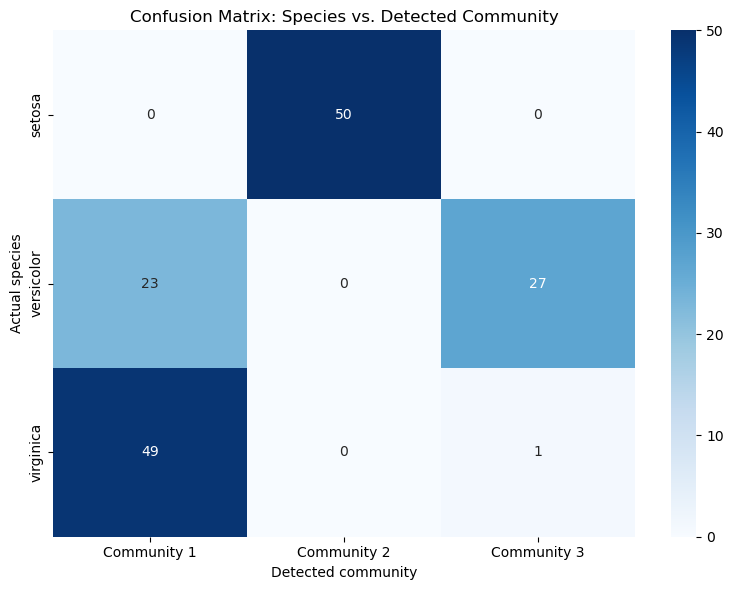


Accuracy (best assignment): 84.0%


In [28]:
# Create a confusion matrix
cm = np.zeros((3, n_communities))
species_order = ['setosa', 'versicolor', 'virginica']

for comm_id, distribution in community_distribution.items():
    for i, species_name in enumerate(species_order):
        cm[i, comm_id] = distribution[species_name]

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=[f'Community {i+1}' for i in range(n_communities)],
            yticklabels=species_order,
            ax=ax)

ax.set_title('Confusion Matrix: Species vs. Detected Community', fontsize=12)
ax.set_ylabel('Actual species')
ax.set_xlabel('Detected community')

plt.tight_layout()
plt.show()

# Calculate accuracy (assuming optimal assignment of communities to species)
# Find best match per community
best_matches = cm.max(axis=0).sum()
accuracy = best_matches / 150
print(f"\nAccuracy (best assignment): {accuracy:.1%}")


**Figure 5: Confusion matrix – comparison of actual species and detected communities.** Heatmap showing the number of flowers from each species (rows) that were placed in each detected community (columns). The numbers in the cells indicate the number of flowers. Perfect classification would give a diagonal matrix with 50 in each diagonal cell. Here we see that setosa (50 flowers) was perfectly grouped into one community (Community 2), while versicolor and virginica show overlap – versicolor is split between Community 1 (27) and Community 3 (23), and almost all virginica (49 of 50) ended up in Community 3. The calculated accuracy of 84% reflects how well the automatically detected communities correspond to the actual biological species.

---

### 🎯 Interpretation

The confusion matrix shows us:
- **Setosa** is identified perfectly – all 50 in one community
- **Versicolor and Virginica** have some overlap – this is expected because these species actually have more similar characteristics

This is an important finding: **network-based analysis can reveal natural groupings in data!**

**Clinical relevance:** In patient data, such communities can represent:
- Different disease subtypes
- Patients with similar treatment response
- Risk groups


---
## 📚 Summary and Next Steps

### What Have We Learned?

1. **Building similarity networks** – transforming feature data to network representation
2. **Calculating similarity** – using Euclidean distance and transformation to similarity measure
3. **Visualizing networks** – seeing structures and clusters in the data
4. **Analyzing network properties** – calculating metrics and comparing groups
5. **Community detection** – finding natural groupings automatically

### From Flowers to Patients

The principles we have learned can be transferred directly to clinical data:

| IRIS data | Patient data |
|-----------|--------------|
| Flower | Patient |
| Petal length, etc. | Lab values, vital signs, etc. |
| Species (setosa, etc.) | Diagnosis or treatment response |
| Similarity network | Patient Similarity Network (PSN) |
| Community | Patient subgroup |

### Next Notebook

In the following notebooks, we will apply these techniques to:
- Synthetic patient data
- IQ data from the ABCD study
- More advanced similarity metrics


---
## 💡 Exercises

Try these 10 exercises to deepen your understanding. Solutions can be found in `02a-patient_similarity_network_iris_solutions.ipynb`.

---

### Exercise 1: Alternative Similarity Measure – Gaussian Kernel ⭐

**Task:** Modify the code to use a Gaussian kernel (RBF) instead of our inverse distance:

$$s_{ij} = \exp\left(-\frac{d_{ij}^2}{2\sigma^2}\right)$$

a) Implement this similarity formula  
b) Experiment with different values of $\sigma$ (0.5, 1.0, 2.0, 5.0)  
c) How does $\sigma$ affect network structure and community detection?

**Motivation:** Gaussian kernel is very common in machine learning (SVM, kernel methods) and provides a "softer" distance function. $\sigma$ controls how quickly similarity decreases with distance.

<details>
<summary>💡 Hint</summary>

```python
sigma = 1.0
similarity = np.exp(-(distance**2) / (2 * sigma**2))
```
Small $\sigma$ → only very close nodes get high similarity  
Large $\sigma$ → all nodes get relatively similar similarity
</details>

---

### Exercise 2: Threshold-Based Sparse Network ⭐

**Task:** Instead of a complete network, build a *sparse* network where only edges with similarity above a threshold are included.

a) Build networks with threshold = 0.3, 0.5, 0.7  
b) Calculate network density for each threshold  
c) Run community detection on each network – do the results change?

**Motivation:** Complete networks are computationally heavy and can "hide" important structures. Sparse networks highlight the strongest connections.

<details>
<summary>💡 Hint</summary>

```python
threshold = 0.5
G_sparse = nx.Graph()
for i in range(len(X)):
    G_sparse.add_node(i, species=species[y[i]])
    for j in range(i+1, len(X)):
        similarity = 1 / (1 + np.linalg.norm(X[i] - X[j]))
        if similarity >= threshold:  # Only add if above threshold
            G_sparse.add_edge(i, j, weight=similarity)
```
</details>

---

### Exercise 3: Clinical Scenario – Design a PSN ⭐⭐

**Task:** Think of a clinical setting where you would use PSN. Describe:

a) Which patient population (e.g., heart failure, diabetes, cancer)?  
b) Which variables would you include (at least 5)?  
c) How would you calculate similarity between patients?  
d) What could communities represent clinically?  
e) How would you validate the results?

**Motivation:** PSN is a tool – the value lies in clinical application. Thinking through a realistic scenario forces understanding of the method's strengths and limitations.

<details>
<summary>💡 Hint – Example: Type 2 Diabetes</summary>

- **Variables:** HbA1c, fasting glucose, BMI, age, blood pressure, cholesterol
- **Similarity measure:** Gower distance (mixture of continuous and categorical)
- **Communities:** Different disease profiles (metabolic syndrome, insulin resistant, etc.)
- **Validation:** Check if communities have different treatment responses
</details>

---

### Exercise 4: Normalize Features Before Distance Calculation ⭐

**Task:** IRIS features have different scales (cm). What happens if we normalize them first?

a) Normalize each feature to mean=0, standard deviation=1 (z-score)  
b) Build a new network with normalized data  
c) Compare community detection results with the original network

**Motivation:** In clinical data, variables have widely different scales (age 0-100, blood pressure 60-200, BMI 15-50). Without normalization, variables with large range will dominate the distance calculation.

<details>
<summary>💡 Hint</summary>

```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
# Build network with X_normalized instead of X
```
</details>

---

### Exercise 5: Compare with K-means ⭐⭐

**Task:** Run K-means clustering (k=3) on the IRIS data and compare with community detection.

a) Implement K-means with scikit-learn  
b) Calculate Adjusted Rand Index (ARI) for both methods against actual species  
c) Which method gives the best result? Why do you think so?

**Motivation:** K-means is a classic clustering method. Comparing provides insight into when network-based methods have advantages.

<details>
<summary>💡 Hint</summary>

```python
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

ari_kmeans = adjusted_rand_score(y, kmeans_labels)
ari_community = adjusted_rand_score(y, list(communities.values()))
```
</details>

---

### Exercise 6: Centrality Analysis – Find "Hub Flowers" ⭐⭐

**Task:** Use centrality measures to find the most "central" flowers in the network.

a) Calculate *degree centrality* and *eigenvector centrality* for all nodes  
b) Find the 5 most central nodes in each species  
c) Are the central nodes "typical" or "atypical" for their species?

**Motivation:** In PSN, central nodes can represent "typical patients" or patients who resemble many others – potentially useful for defining patient profiles.

<details>
<summary>💡 Hint</summary>

```python
# Degree centrality
degree_cent = nx.degree_centrality(G)

# Eigenvector centrality (use weights)
eigen_cent = nx.eigenvector_centrality(G, weight='weight')

# Find top 5 for setosa
setosa_nodes = [n for n in G.nodes() if G.nodes[n]['species'] == 'setosa']
setosa_top5 = sorted(setosa_nodes, key=lambda n: eigen_cent[n], reverse=True)[:5]
```
</details>

---

### Exercise 7: Visualize Only One Species ⭐

**Task:** Create a sub-network containing only flowers of one species (e.g., versicolor).

a) Extract the sub-network for versicolor  
b) Visualize it  
c) Are there sub-communities *within* versicolor?

**Motivation:** In clinical PSN, one often zooms in on one patient group to find subtypes. This exercise trains that skill.

<details>
<summary>💡 Hint</summary>

```python
# Find nodes that are versicolor
versicolor_nodes = [n for n in G.nodes() if G.nodes[n]['species'] == 'versicolor']

# Create subgraph
G_versicolor = G.subgraph(versicolor_nodes).copy()

# Community detection on subgraph
sub_communities = community.best_partition(G_versicolor)
```
</details>

---

### Exercise 8: Robustness – Remove Random Nodes ⭐⭐

**Task:** Investigate how robust community detection is to missing data.

a) Randomly remove 10%, 20%, 30% of the nodes  
b) Run community detection on each reduced network  
c) Calculate ARI against original result for each level  
d) At what level does the structure break down?

**Motivation:** Clinical data is often incomplete. Understanding the method's robustness is important to know how much you can trust the results.

<details>
<summary>💡 Hint</summary>

```python
import random

def test_robustness(G, remove_fraction):
    nodes_to_keep = random.sample(list(G.nodes()), int(len(G.nodes()) * (1 - remove_fraction)))
    G_reduced = G.subgraph(nodes_to_keep).copy()
    communities_reduced = community.best_partition(G_reduced)
    return communities_reduced

# Test with 10% removal
communities_90 = test_robustness(G, 0.10)
```
</details>

---

### Exercise 9: Manhattan Distance vs. Euclidean ⭐

**Task:** Replace Euclidean distance with Manhattan distance (L1-norm).

a) Implement Manhattan distance: $d_{ij} = \sum_k |X_{ik} - X_{jk}|$  
b) Build a new network with Manhattan-based similarity  
c) Compare community detection results

**Motivation:** Choice of distance measure affects which patients are considered "similar". Manhattan distance is more robust to outliers.

<details>
<summary>💡 Hint</summary>

```python
# Manhattan distance
distance_manhattan = np.sum(np.abs(X[i] - X[j]))
# or
from scipy.spatial.distance import cityblock
distance_manhattan = cityblock(X[i], X[j])
```
</details>

---

### Exercise 10: Create an Interactive Threshold Slider ⭐⭐⭐

**Task:** Create an interactive visualization with ipywidgets where the user can adjust the similarity threshold with a slider.

a) Use `ipywidgets.interact` to create a slider for threshold (0.2 to 0.8)  
b) Update the network visualization dynamically  
c) Show number of edges and network density for each threshold value

**Motivation:** Interactive tools provide faster insight and are valuable for data exploration.

<details>
<summary>💡 Hint</summary>

```python
import ipywidgets as widgets
from IPython.display import display, clear_output

def plot_network_with_threshold(threshold=0.5):
    clear_output(wait=True)
    # Filter edges
    edges_to_show = [(u, v) for u, v in G.edges() if G[u][v]['weight'] >= threshold]
    # Draw...
    print(f"Threshold: {threshold}, Number of edges: {len(edges_to_show)}")

widgets.interact(plot_network_with_threshold, threshold=(0.2, 0.8, 0.05))
```
</details>


---
## 📖 References

### Core References Used in This Notebook

- **Iris dataset**: Fisher, R.A. (1936). "[The use of multiple measurements in taxonomic problems](https://onlinelibrary.wiley.com/doi/10.1111/j.1469-1809.1936.tb02137.x)". *Annals of Eugenics*, 7(2), 179-188.

- **NetworkX**: Hagberg, A., Swart, P., & Chult, D.S. (2008). "[Exploring network structure, dynamics, and function using NetworkX](https://conference.scipy.org/proceedings/scipy2008/paper_2/)". *Proceedings of the 7th Python in Science Conference (SciPy2008)*.

- **Louvain community detection**: Blondel, V.D., Guillaume, J.L., Lambiotte, R., & Lefebvre, E. (2008). "[Fast unfolding of communities in large networks](https://iopscience.iop.org/article/10.1088/1742-5468/2008/10/P10008)". *Journal of Statistical Mechanics: Theory and Experiment*, P10008.

- **Patient Similarity Networks**: Huang, S., Cai, N., Pacheco, P.P., Narrandes, S., Wang, Y., & Xu, W. (2018). "[Patient Similarity Networks for Precision Medicine](https://pubmed.ncbi.nlm.nih.gov/29860027/)". *Journal of Molecular Diagnostics*, 20(5), 537-549.

---

### Extended Reading: Patient Similarity Networks (PSN)

#### Introductions and Review Articles

- **Li, L., et al. (2015)**. "[Identification of type 2 diabetes subgroups through topological analysis of patient similarity](https://www.science.org/doi/10.1126/scitranslmed.aaa9364)". *Science Translational Medicine*, 7(311). — *Groundbreaking study showing clinical utility of PSN for identifying diabetes subtypes.*

- **Ng, K., et al. (2015)**. "[Personalized Predictive Modeling and Risk Factor Identification using Patient Similarity](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5001752/)". *AMIA Joint Summits on Translational Science*. — *Good introduction to PSN methodology.*

- **Parimbelli, E., et al. (2018)**. "[Patient similarity for precision medicine: A systematic review](https://doi.org/10.1016/j.jbi.2018.06.001)". *Journal of Biomedical Informatics*, 83, 87-96. — *Comprehensive systematic review of the field.*

#### Advanced Methods and Extensions

- **Wang, B., et al. (2014)**. "[Similarity network fusion for aggregating data types on a genomic scale](https://www.nature.com/articles/nmeth.2810)". *Nature Methods*, 11(3), 333-337. — *Spectral fusion of multiple data types into one network.*

- **Gower, J.C. (1971)**. "[A General Coefficient of Similarity and Some of Its Properties](https://www.jstor.org/stable/2528823)". *Biometrics*, 27(4), 857-871. — *Classic article on Gower distance for mixed data types.*

#### Network Science in General

- **Barabási, A.L. (2016)**. *[Network Science](http://networksciencebook.com/)*. Cambridge University Press. — *Free online textbook! Excellent introduction to network science.*

- **Newman, M.E.J. (2010)**. *Networks: An Introduction*. Oxford University Press. — *Comprehensive reference work for network analysis.*

#### Clustering and Community Detection

- **Fortunato, S. (2010)**. "[Community detection in graphs](https://www.sciencedirect.com/science/article/abs/pii/S0370157309002841)". *Physics Reports*, 486(3-5), 75-174. — *Classic overview of community detection methods.*

- **von Luxburg, U. (2007)**. "[A tutorial on spectral clustering](https://link.springer.com/article/10.1007/s11222-007-9033-z)". *Statistics and Computing*, 17(4), 395-416. — *Good mathematical introduction to spectral clustering.*

---

### Useful Tools and Resources

- **[NetworkX documentation](https://networkx.org/documentation/stable/)** — Official documentation with examples
- **[Graph-tool](https://graph-tool.skewed.de/)** — Faster alternative to NetworkX for large networks
- **[Gephi](https://gephi.org/)** — Interactive network visualization (GUI-based)
- **[Cytoscape](https://cytoscape.org/)** — Popular in bioinformatics for network visualization
